In [7]:
import pandas
import numpy
import yfinance

[*********************100%***********************]  2 of 2 completed

--- Success! First 5 rows of your Spread ---
Date
2024-05-15   -0.913374
2024-05-16   -0.859824
2024-05-17   -0.832243
2024-05-20   -0.706118
2024-05-21   -0.656204
Name: Spread, dtype: float64


<Axes: title={'center': 'NNE-OKLO Pair Spread'}, xlabel='Date'>

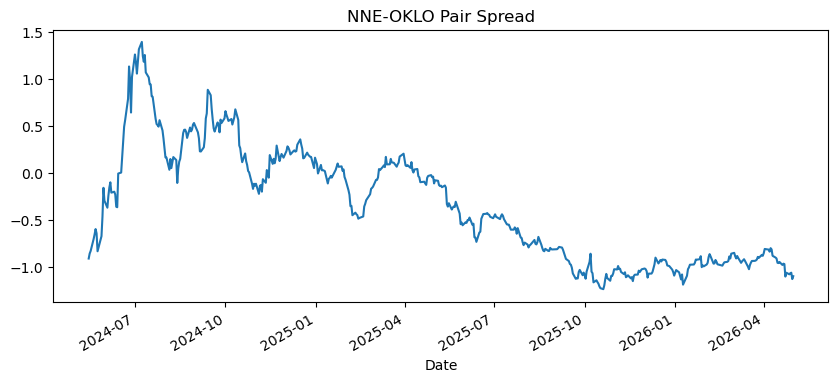

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ['NNE', 'OKLO']

raw_data = yf.download(tickers, start='2024-05-15', auto_adjust=False)

data = raw_data['Adj Close'].copy()

data = data.dropna()

data['Spread'] = np.log(data['NNE']) - np.log(data['OKLO'])

print("--- Success! First 5 rows of your Spread ---")
print(data['Spread'].head())

data['Spread'].plot(figsize=(10,4), title='NNE-OKLO Pair Spread')

In [10]:
data['Spread_Change'] = data['Spread'].diff()

spread_changes = data['Spread_Change'].dropna()

print("Average Daily Change:", spread_changes.mean())

Average Daily Change: -0.0003821916026981804


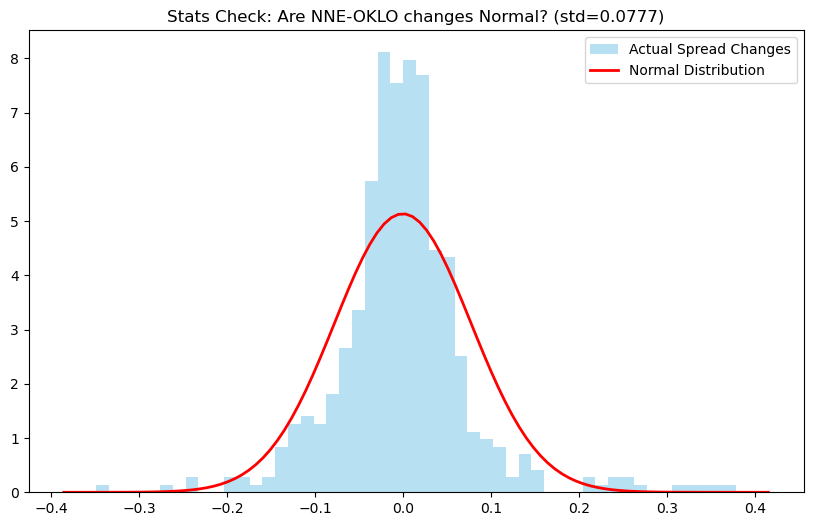

In [11]:
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.figure(figsize=(10, 6))
plt.hist(spread_changes, bins=50, density=True, alpha=0.6, color='skyblue', label='Actual Spread Changes')

mu, std = spread_changes.mean(), spread_changes.std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r', linewidth=2, label='Normal Distribution')
plt.title(f'Stats Check: Are NNE-OKLO changes Normal? (std={std:.4f})')
plt.legend()
plt.show()

In [12]:
# Nope, it's a leptokurtic distribution:
#The actual spread changes are noticeably taller and narrower in the center than the fitted normal curve.

In [13]:
#The model has excess kurtosis, indicating that both the tickers OKLO and NNE are rather speculative and momentum driven stocks.

In [15]:
from scipy import stats

y = data['Spread'].values
y_delayed = y[:-1]   
y_current = y[1:]  
delta_y = y_current - y_delayed 

slope, intercept, r_value, p_value, std_err = stats.linregress(y_delayed, delta_y)

theta = -slope
mu = -intercept / slope
residuals = delta_y - (intercept + slope * y_delayed)
sigma = np.std(residuals)

print(f"OU Model Calibrated")
print(f"Mean Reversion Speed (Theta): {theta:.4f}")
print(f"Equilibrium Level (Mu): {mu:.4f}")
print(f"Daily Volatility (Sigma): {sigma:.4f}")

half_life = np.log(2) / theta
print(f"Trading Half-Life: {half_life:.2f} days")


OU Model Calibrated
Mean Reversion Speed (Theta): 0.0075
Equilibrium Level (Mu): -0.4057
Daily Volatility (Sigma): 0.0775
Trading Half-Life: 92.27 days


In [16]:
#For the data above, I decided to use the Dickey-Fuller test!